<a href="https://colab.research.google.com/github/SonicWD/deep_learning/blob/main/week5/actividad5/Actividad5_Clasificacion_Multiclase_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semana 5 – Actividad 5: Clasificación multiclase (MLP, TensorFlow Keras)

**Curso:** Deep Learning - Conceptos (601539) · FU / CAD2202023205 / EIAIPA2026 · Semana 5

Red **fully connected** (sin convolución) sobre el dataset **Digits** de scikit-learn (10 clases). Se comparan **optimizadores** y el efecto de **tasa de aprendizaje**, **tamaño de lote** y **épocas**, con la misma partición de datos y semillas para resultados **reproducibles**.

**Enlaces (tras `git push` al repo público):**
- Carpeta **week5/**: [github.com/SonicWD/deep_learning/tree/main/week5](https://github.com/SonicWD/deep_learning/tree/main/week5)
- **Abrir en Google Colab**: [Abrir notebook en Colab](https://colab.research.google.com/github/SonicWD/deep_learning/blob/main/week5/actividad5/Actividad5_Clasificacion_Multiclase_Keras.ipynb)


### Ejecución recomendada

**Google Colab:** *Entorno → Ejecutar todo*. Colab incluye TensorFlow compatible; la siguiente celda completa dependencias si algo falta.

**Windows local:** si TensorFlow falla, use **Python 3.12** (venv) o active [rutas largas](https://learn.microsoft.com/en-us/windows/win32/fileio/maximum-file-path-limitation). En **Python 3.14** TensorFlow estable a menudo **no** está disponible.


In [1]:
import subprocess
import sys

_PKGS = ["tensorflow", "scikit-learn", "matplotlib", "numpy", "pandas"]


def _pip(*args):
    return subprocess.run([sys.executable, "-m", "pip", *args], capture_output=True, text=True)


def _ensure_tensorflow():
    try:
        import tensorflow as tf  # noqa: F401

        _ = tf.__version__
        return
    except Exception:
        pass
    _pip("uninstall", "-y", "tensorflow", "tensorflow-intel")
    r = _pip("install", "-q", *_PKGS)
    if r.returncode != 0:
        print(r.stdout)
        print(r.stderr)
        raise RuntimeError(
            "No se pudo instalar TensorFlow. Use Google Colab o Python 3.12. Ver week5/README.md"
        )


_ensure_tensorflow()

for _name, _pipn in (
    ("sklearn", "scikit-learn"),
    ("matplotlib", "matplotlib"),
    ("numpy", "numpy"),
    ("pandas", "pandas"),
):
    try:
        __import__(_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", _pipn])

import tensorflow as tf

print("Listo — TensorFlow", tf.__version__)


Listo — TensorFlow 2.19.0


## 1. Dataset y preparación

- **Digits:** 1797 muestras, 64 características (imagen 8×8 aplanada), 10 clases (dígitos 0–9).
- Partición **estratificada:** train / validación / test.
- **StandardScaler** ajustado solo sobre train.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

X, y = load_digits(return_X_y=True)
n_classes = len(np.unique(y))
n_features = X.shape[1]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.astype(np.float32))
X_val = scaler.transform(X_val.astype(np.float32))
X_test = scaler.transform(X_test.astype(np.float32))

print(f"Features: {n_features} | Clases: {n_classes}")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")


Features: 64 | Clases: 10
Train: (1149, 64) | Val: (288, 64) | Test: (360, 64)


## 2. Arquitectura MLP (multicategoría)

- Capas densas **ReLU** y salida **softmax** (10 neuronas).
- Pérdida: `sparse_categorical_crossentropy` (etiquetas enteras).
- Métrica: `accuracy`.

Función reutilizable `build_model(optimizer)` para que **solo cambie el optimizador** o los hiperparámetros que se estudien.


In [3]:
def build_model(optimizer):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train_model(optimizer, epochs=80, batch_size=32, verbose=0):
    model = build_model(optimizer)
    hist = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
    )
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    return model, hist, test_loss, test_acc


## 3. Comparación de optimizadores

Mismas condiciones: **80 épocas**, **batch 32**, misma arquitectura y datos. Se usan tasas de aprendizaje **típicas** por optimizador (comentadas en código); el propósito es observar **curvas** y **accuracy en test**.


In [4]:
EPOCHS_OPT = 80
BATCH_OPT = 32

runs_opt = []
runs_opt.append(("SGD (momentum=0.9)", tf.keras.optimizers.SGD(learning_rate=0.05, momentum=0.9)))
runs_opt.append(("Adam", tf.keras.optimizers.Adam(learning_rate=1e-3)))
runs_opt.append(("RMSprop", tf.keras.optimizers.RMSprop(learning_rate=1e-3)))

histories_opt = {}
test_results_opt = {}
for name, opt in runs_opt:
    _, h, te_loss, te_acc = train_model(opt, epochs=EPOCHS_OPT, batch_size=BATCH_OPT, verbose=0)
    histories_opt[name] = h.history
    test_results_opt[name] = {"test_loss": float(te_loss), "test_accuracy": float(te_acc)}
    print(f"{name}: test accuracy = {te_acc:.4f}, test loss = {te_loss:.4f}")


SGD (momentum=0.9): test accuracy = 0.9778, test loss = 0.2467
Adam: test accuracy = 0.9861, test loss = 0.1066
RMSprop: test accuracy = 0.9722, test loss = 0.2284


## 4. Hiperparámetro: tasa de aprendizaje (Adam)

Fijamos **Adam** y **batch 32**, **80 épocas**. Se prueban tres valores de `learning_rate`.


In [5]:
EPOCHS_LR = 80
BATCH_LR = 32
lr_list = [1e-2, 1e-3, 1e-4]
histories_lr = {}
test_results_lr = {}
for lr in lr_list:
    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    _, h, te_loss, te_acc = train_model(opt, epochs=EPOCHS_LR, batch_size=BATCH_LR, verbose=0)
    key = f"Adam lr={lr}"
    histories_lr[key] = h.history
    test_results_lr[key] = {"test_loss": float(te_loss), "test_accuracy": float(te_acc)}
    print(f"{key}: test accuracy = {te_acc:.4f}")


Adam lr=0.01: test accuracy = 0.9611
Adam lr=0.001: test accuracy = 0.9694
Adam lr=0.0001: test accuracy = 0.9694


## 5. Hiperparámetro: tamaño de lote

Mismo **Adam (lr=1e-3)**, **80 épocas**. Batch pequeño implica más ruido por actualización; batch grande reduce el número de actualizaciones por época.


In [6]:
EPOCHS_BS = 80
LR_BS = 1e-3
batch_sizes = [8, 32, 128]
histories_bs = {}
test_results_bs = {}
for bs in batch_sizes:
    opt = tf.keras.optimizers.Adam(learning_rate=LR_BS)
    _, h, te_loss, te_acc = train_model(opt, epochs=EPOCHS_BS, batch_size=bs, verbose=0)
    key = f"batch={bs}"
    histories_bs[key] = h.history
    test_results_bs[key] = {"test_loss": float(te_loss), "test_accuracy": float(te_acc)}
    print(f"{key}: test accuracy = {te_acc:.4f}")


batch=8: test accuracy = 0.9778
batch=32: test accuracy = 0.9722
batch=128: test accuracy = 0.9722


## 6. Gráficos y tabla resumen


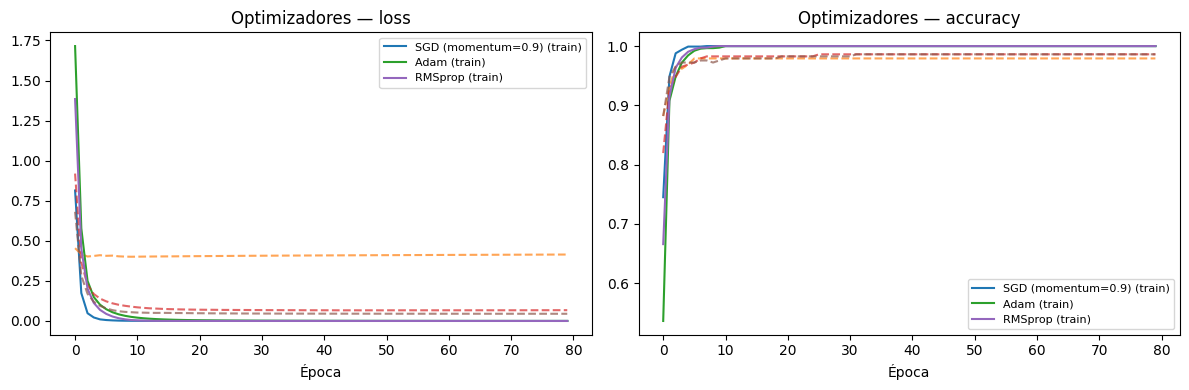

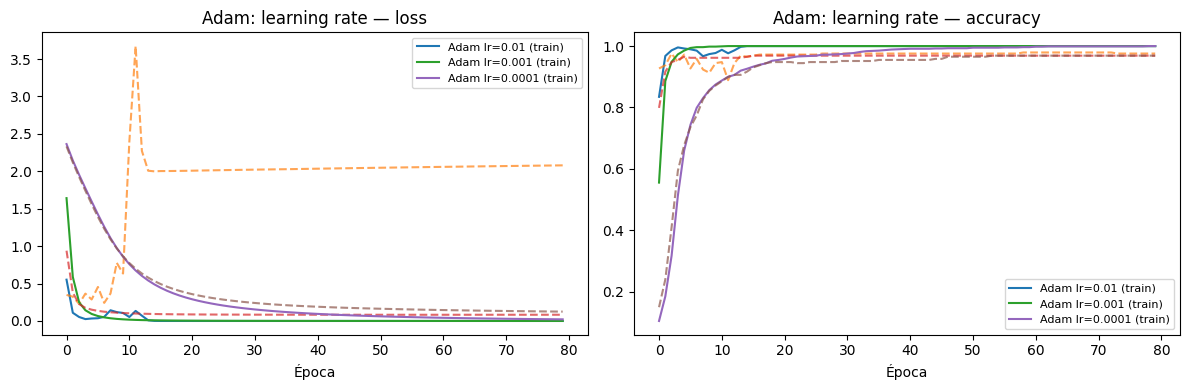

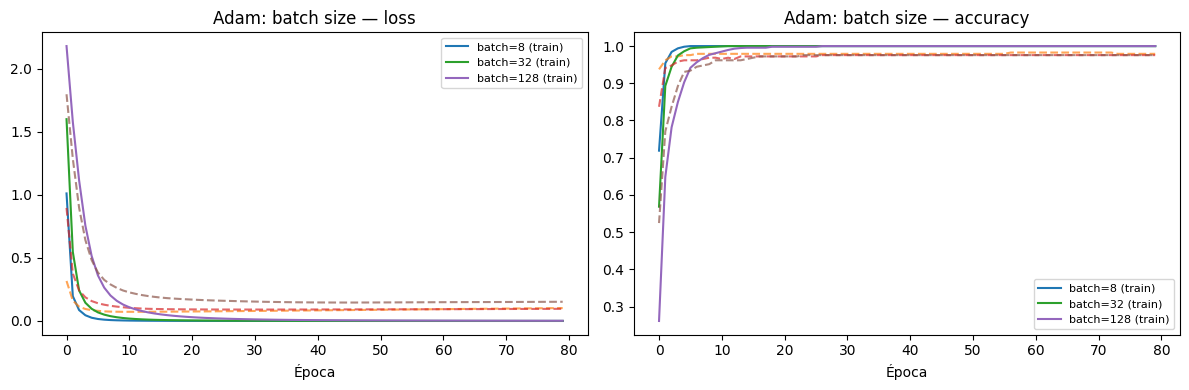

,experimento,config,test_loss,test_accuracy
6,batch,batch=8,0.192227,0.977778
7,batch,batch=32,0.117485,0.972222
8,batch,batch=128,0.122481,0.972222
4,lr,Adam lr=0.001,0.132339,0.969444
5,lr,Adam lr=0.0001,0.119458,0.969444
3,lr,Adam lr=0.01,0.819369,0.961111
1,optimizador,Adam,0.106589,0.986111
0,optimizador,SGD (momentum=0.9),0.246722,0.977778
2,optimizador,RMSprop,0.228353,0.972222


In [7]:
try:
    from IPython.display import display
except ImportError:
    display = print

def plot_group(hdict, title_prefix):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for label, h in hdict.items():
        ax[0].plot(h["loss"], label=f"{label} (train)")
        ax[0].plot(h["val_loss"], linestyle="--", alpha=0.7)
    ax[0].set_title(f"{title_prefix} — loss")
    ax[0].set_xlabel("Época")
    ax[0].legend(fontsize=8)
    for label, h in hdict.items():
        ax[1].plot(h["accuracy"], label=f"{label} (train)")
        ax[1].plot(h["val_accuracy"], linestyle="--", alpha=0.7)
    ax[1].set_title(f"{title_prefix} — accuracy")
    ax[1].set_xlabel("Época")
    ax[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()


plot_group(histories_opt, "Optimizadores")
plot_group(histories_lr, "Adam: learning rate")
plot_group(histories_bs, "Adam: batch size")

rows = []
for k, v in test_results_opt.items():
    rows.append({"experimento": "optimizador", "config": k, **v})
for k, v in test_results_lr.items():
    rows.append({"experimento": "lr", "config": k, **v})
for k, v in test_results_bs.items():
    rows.append({"experimento": "batch", "config": k, **v})

df = pd.DataFrame(rows)
display(df.sort_values(["experimento", "test_accuracy"], ascending=[True, False]))


## 7. Análisis y conclusiones breves (Markdown — consigna)

Redacte **3–6 frases por apartado** apoyándose en las **curvas** (suavidad, oscilaciones, brecha train–val) y en la **tabla** de `test_accuracy` / `test_loss`. Criterios de la actividad: **estabilidad**, **velocidad de convergencia** y **hallazgos** al variar hiperparámetros u optimizador.

### Estabilidad

- ¿Qué configuración muestra **menos oscilación** en `val_loss` o en `val_accuracy`?
- ¿Algún `learning_rate` u optimizador produce curvas **irregulares** o divergencia?

### Velocidad de convergencia

- ¿Qué optimizador o `lr` alcanza antes una `val_loss` baja o una `val_accuracy` alta (p. ej. en las primeras 20–40 épocas)?
- ¿`1e-4` queda **corto** de tiempo (mismas 80 épocas) frente a `1e-3`?

### Hallazgos al ajustar hiperparámetros y optimización

- **Optimizadores:** diferencias claras entre SGD+momentum, Adam y RMSprop en este problema.
- **Learning rate (Adam):** trade-off entre velocidad e inestabilidad al subir/bajar `lr`.
- **Batch size:** relación entre tamaño de lote, **ruido** del gradiente y pasos por época.

### Limitaciones (opcional, 1–2 frases)

MLP sobre 64 características; sin convolución no se explota explícitamente la estructura 8×8 (en Digits suele ser aceptable).

---
*Evidencia reproducible: `RANDOM_STATE`, `tf.random.set_seed`, hiperparámetros en código, figuras y tabla.*
